In [6]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import os

def save_fig(name):
    plt.savefig(os.path.join("../Data", name), dpi=300, bbox_inches='tight')


name = 'img.jpg'
image = cv2.imread(name)
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 1. Зашумить изображение при помощи шума гаусса, постоянного шума

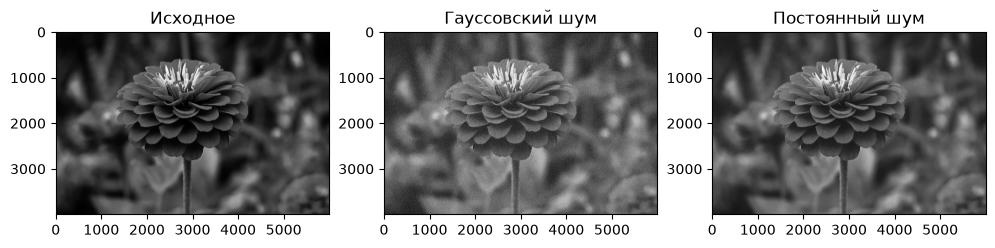

In [7]:
plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.title("Исходное")
plt.imshow(image_gray, cmap='gray')


# Шум Гаусса
mean = 0
stddev = 100
gauss_noise = np.zeros_like(image_gray, dtype=np.uint8)
cv2.randn(gauss_noise, mean, stddev)

image_gauss_noisy = cv2.add(image_gray, gauss_noise)

plt.subplot(1,3,2)
plt.title("Гауссовский шум")
plt.imshow(image_gauss_noisy, cmap='gray')


# Постоянный шум
constant_noise = np.random.randint(0, 50, size=image_gray.shape, dtype=np.uint8)
image_const_noisy = cv2.add(image_gray, constant_noise)

plt.subplot(1,3,3)
plt.title("Постоянный шум")
plt.imshow(image_const_noisy, cmap='gray')

save_fig("First.png")

# 2. Протестировать медианный фильтр, фильтр гаусса, билатериальный фильтр, фильтр нелокальных средних с различными параметрами.

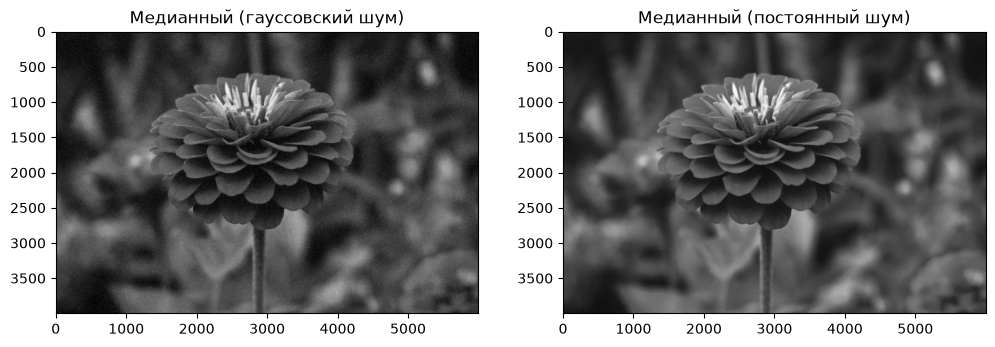

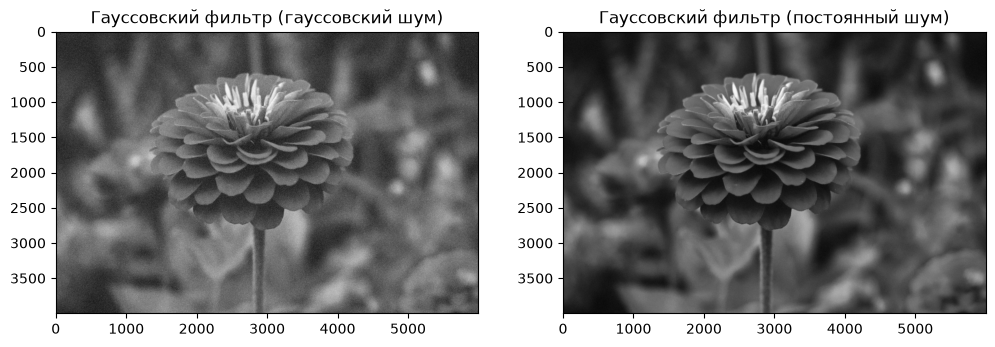

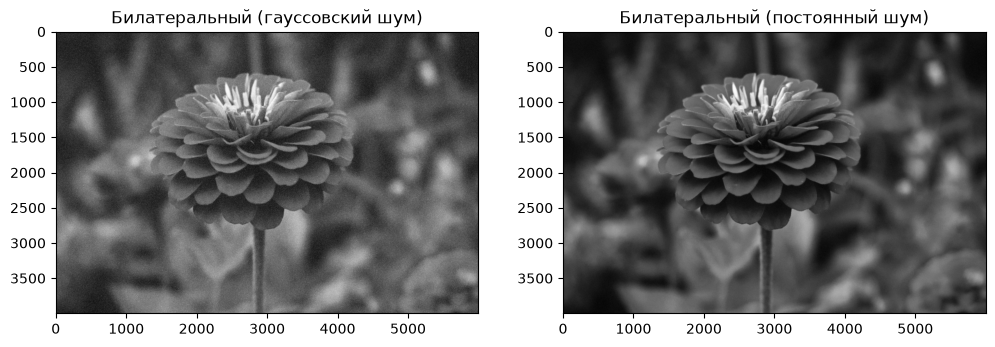

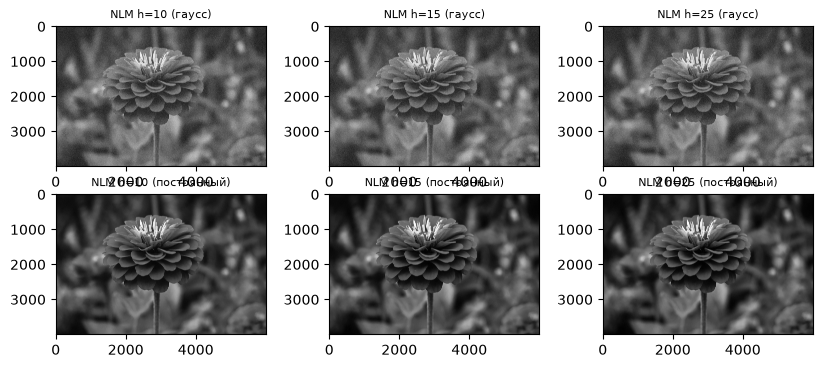

In [8]:
# Медианный фильтр
median_gauss = cv2.medianBlur(image_gauss_noisy, 5)
median_const = cv2.medianBlur(image_const_noisy, 5)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Медианный (гауссовский шум)")
plt.imshow(median_gauss, cmap='gray')


plt.subplot(1,2,2)
plt.title("Медианный (постоянный шум)")
plt.imshow(median_const, cmap='gray')

save_fig("Mediam.png")

# Гауссовский фильтр
gauss_f_gauss = cv2.GaussianBlur(image_gauss_noisy, (5,5), 1.5)
gauss_f_const = cv2.GaussianBlur(image_const_noisy, (5,5), 1.5)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Гауссовский фильтр (гауссовский шум)")
plt.imshow(gauss_f_gauss, cmap='gray')


plt.subplot(1,2,2)
plt.title("Гауссовский фильтр (постоянный шум)")
plt.imshow(gauss_f_const, cmap='gray')

save_fig("Gaus.png")

# Билатеральный фильтр
bilateral_gauss = cv2.bilateralFilter(image_gauss_noisy, d=9, sigmaColor=75, sigmaSpace=75)
bilateral_const = cv2.bilateralFilter(image_const_noisy, d=9, sigmaColor=75, sigmaSpace=75)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Билатеральный (гауссовский шум)")
plt.imshow(bilateral_gauss, cmap='gray')


plt.subplot(1,2,2)
plt.title("Билатеральный (постоянный шум)")
plt.imshow(bilateral_const, cmap='gray')

save_fig("Bilater.png")


# Нелокальные средние
h_values = [10, 15, 25]

nlm_gauss_results = []
nlm_const_results = []

for h in h_values:
    nlm_gauss_results.append(
        cv2.fastNlMeansDenoising(image_gauss_noisy, None, h=h, templateWindowSize=7, searchWindowSize=21)
    )
    nlm_const_results.append(
        cv2.fastNlMeansDenoising(image_const_noisy, None, h=h, templateWindowSize=7, searchWindowSize=21)
    )

plt.figure(figsize=(10,4))

for i, h in enumerate(h_values):
    plt.subplot(2, len(h_values), i+1)
    plt.title(f"NLM h={h} (гаусс)", fontsize=8)
    plt.imshow(nlm_gauss_results[i], cmap='gray')
    plt.xticks([])
    plt.yticks([])
    plt.axis('off')

    plt.subplot(2, len(h_values), len(h_values)+i+1)
    plt.title(f"NLM h={h} (постоянный)", fontsize=8)
    plt.imshow(nlm_const_results[i], cmap='gray')
    plt.xticks([])
    plt.yticks([])
    plt.axis('off')

save_fig("NoLocal_params.png")


# 3. Выяснить, какой фильтр показал лучший результат фильтрации шума.

In [9]:
def evaluate_filter(original, filtered):
    psnr = float(peak_signal_noise_ratio(original, filtered))
    ssim = float(structural_similarity(original, filtered))
    return psnr, ssim


# Оценка для гауссовского шума
print("Гауссовский шум:")
print("Median:", evaluate_filter(image_gray, median_gauss))
print("Gaussian:", evaluate_filter(image_gray, gauss_f_gauss))
print("Bilateral:", evaluate_filter(image_gray, bilateral_gauss))

for i, h in enumerate(h_values):
    print(f"NLM h={h}:", evaluate_filter(image_gray, nlm_gauss_results[i]))

print("\nПостоянный шум:")
print("Median:", evaluate_filter(image_gray, median_const))
print("Gaussian:", evaluate_filter(image_gray, gauss_f_const))
print("Bilateral:", evaluate_filter(image_gray, bilateral_const))

for i, h in enumerate(h_values):
    print(f"NLM h={h}:", evaluate_filter(image_gray, nlm_const_results[i]))

Гауссовский шум:
Median: (22.888986280625126, 0.3650009204383486)
Gaussian: (15.936536058697492, 0.30399658568446103)
Bilateral: (15.605424334312612, 0.10453307792372918)
NLM h=10: (11.597580035898032, 0.02610488435681721)
NLM h=15: (11.598761514977074, 0.027123466333233915)
NLM h=25: (11.938165558840799, 0.03653700000699399)

Постоянный шум:
Median: (20.10611934358813, 0.5983065742977446)
Gaussian: (20.20614553725009, 0.6847636653726565)
Bilateral: (20.236310170349938, 0.7141535449923717)
NLM h=10: (20.216499456417466, 0.6889753729683031)
NLM h=15: (20.263278652877506, 0.7348083675992738)
NLM h=25: (20.257221882976694, 0.7292035939726202)


При гауссовском шуме наилучший результат - медианный фильтр.
При постоянном шуме — фильтр нелокальных средних (NLM), оптимальный параметр h=15.